Accuracy: 0.956140350877193

Confusion Matrix:
[[71  0]
 [ 5 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        71
           1       1.00      0.88      0.94        43

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



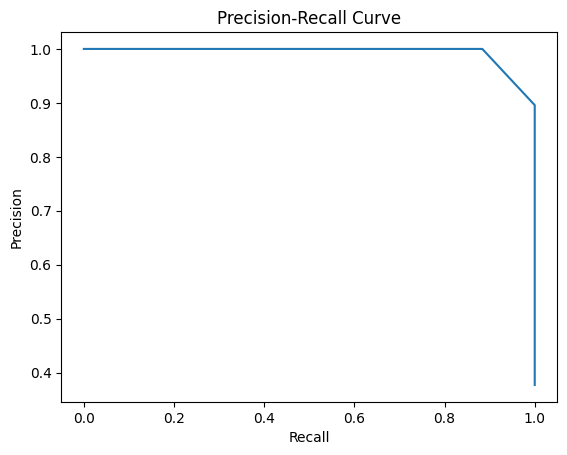

In [2]:
#Exp 1
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import LabelEncoder

# Load Dataset
data = pd.read_csv("wdbc.data", header=None)

# Assign Column Names
columns = ['ID','Diagnosis'] + [f'Feature_{i}' for i in range(1,31)]
data.columns = columns

# Encode Diagnosis Column (M=1, B=0)
label = LabelEncoder()
data['Diagnosis'] = label.fit_transform(data['Diagnosis'])

# Split Features and Target
X = data.drop(['ID','Diagnosis'], axis=1)
y = data['Diagnosis']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict Test Data
y_pred = knn.predict(X_test)

# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Precision-Recall Curve
y_prob = knn.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Accuracy: 0.9473684210526315

Confusion Matrix:
[[68  3]
 [ 3 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



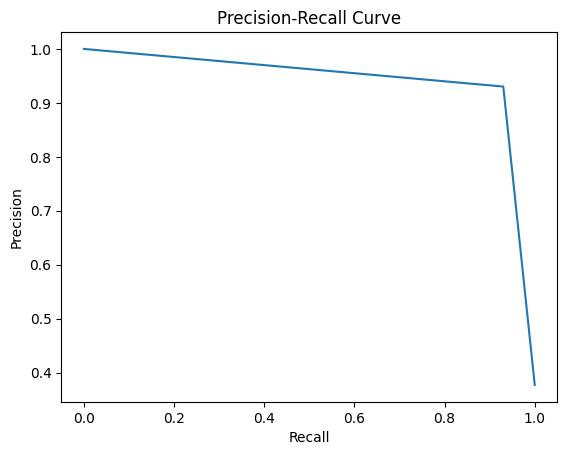

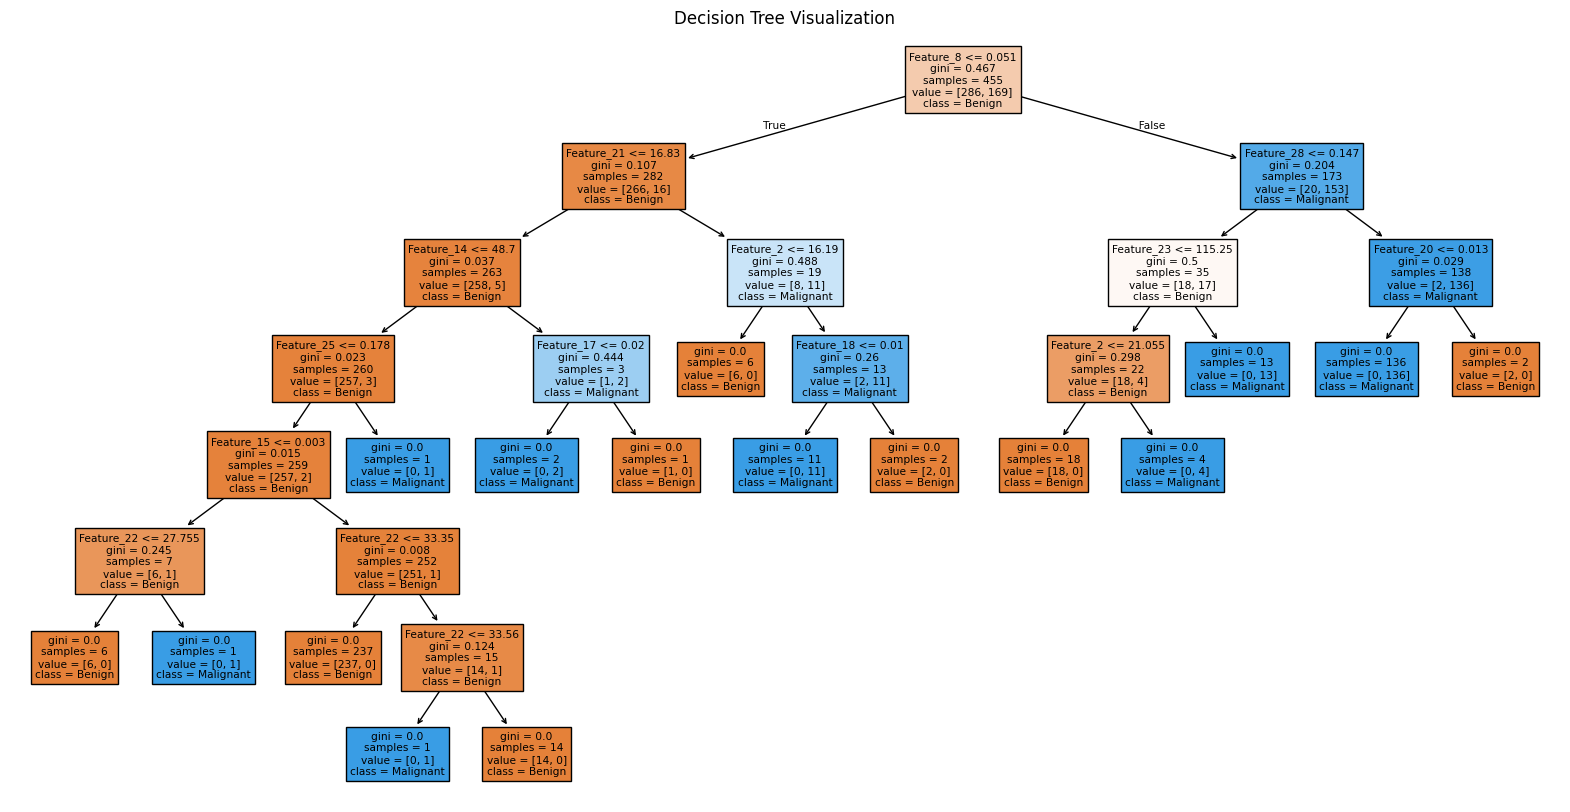

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import LabelEncoder

# Load Dataset
data = pd.read_csv("wdbc.data", header=None)

# Assign Column Names
columns = ['ID','Diagnosis'] + [f'Feature_{i}' for i in range(1,31)]
data.columns = columns

# Convert Diagnosis column (M=1, B=0)
label = LabelEncoder()
data['Diagnosis'] = label.fit_transform(data['Diagnosis'])

# Split Features and Target
X = data.drop(['ID','Diagnosis'], axis=1)
y = data['Diagnosis']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict Test Data
y_pred = dt.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Precision-Recall Curve
y_prob = dt.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Visualize Decision Tree
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Benign","Malignant"],
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

KNN Training Accuracy: 0.9802197802197802
KNN Testing Accuracy: 0.9473684210526315
SVM Training Accuracy: 0.9868131868131869
SVM Testing Accuracy: 0.9736842105263158


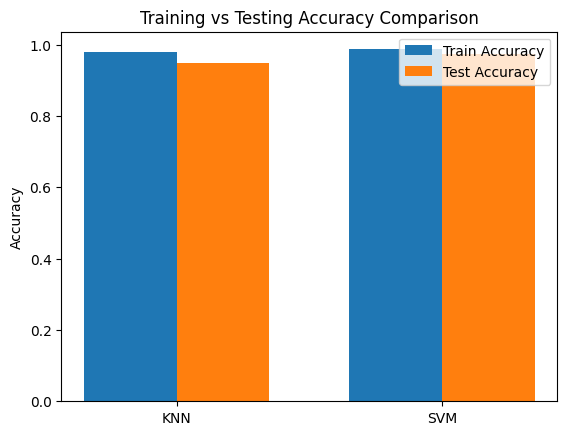

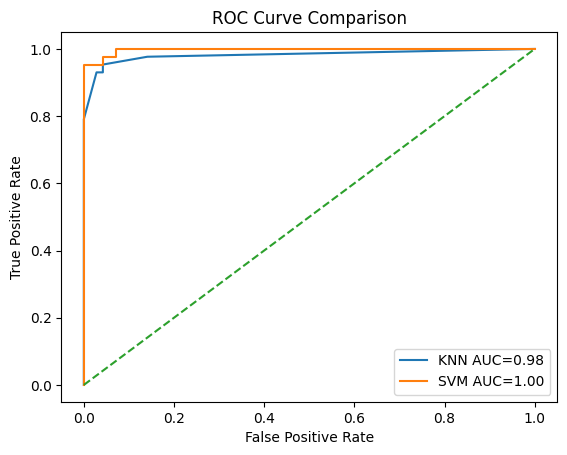

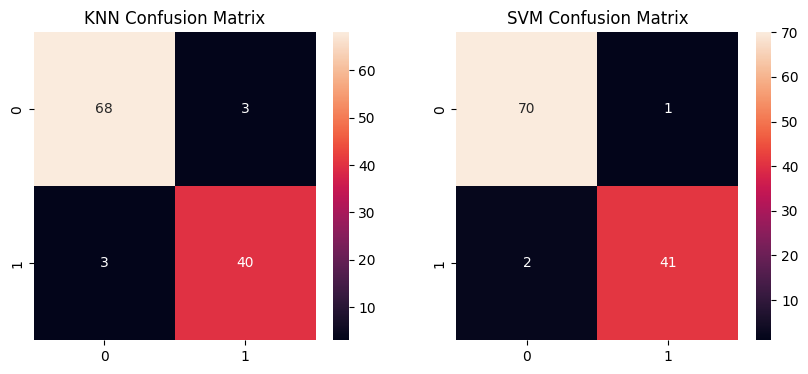

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc

# Load Dataset
data = pd.read_csv("wdbc.data", header=None)

# Assign column names
columns = ['ID','Diagnosis'] + [f'Feature_{i}' for i in range(1,31)]
data.columns = columns

# Encode Diagnosis column (M=1, B=0)
le = LabelEncoder()
data['Diagnosis'] = le.fit_transform(data['Diagnosis'])

# Split features and target
X = data.drop(['ID','Diagnosis'], axis=1)
y = data['Diagnosis']

# Feature Scaling (important for SVM & KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Models
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(probability=True)

knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Predictions
knn_train_pred = knn.predict(X_train)
knn_test_pred = knn.predict(X_test)

svm_train_pred = svm.predict(X_train)
svm_test_pred = svm.predict(X_test)

# Accuracy Calculation
knn_train_acc = accuracy_score(y_train, knn_train_pred)
knn_test_acc = accuracy_score(y_test, knn_test_pred)

svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)

print("KNN Training Accuracy:", knn_train_acc)
print("KNN Testing Accuracy:", knn_test_acc)

print("SVM Training Accuracy:", svm_train_acc)
print("SVM Testing Accuracy:", svm_test_acc)

# ----------------------------------
# Bar Chart for Training vs Testing Accuracy
# ----------------------------------

models = ['KNN','SVM']
train_acc = [knn_train_acc, svm_train_acc]
test_acc = [knn_test_acc, svm_test_acc]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, train_acc, width, label='Train Accuracy')
plt.bar(x + width/2, test_acc, width, label='Test Accuracy')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.show()

# ----------------------------------
# ROC Curve Comparison
# ----------------------------------

knn_prob = knn.predict_proba(X_test)[:,1]
svm_prob = svm.predict_proba(X_test)[:,1]

knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)

knn_auc = auc(knn_fpr, knn_tpr)
svm_auc = auc(svm_fpr, svm_tpr)

plt.figure()
plt.plot(knn_fpr, knn_tpr, label=f'KNN AUC={knn_auc:.2f}')
plt.plot(svm_fpr, svm_tpr, label=f'SVM AUC={svm_auc:.2f}')

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ----------------------------------
# Confusion Matrix Heatmap
# ----------------------------------

knn_cm = confusion_matrix(y_test, knn_test_pred)
svm_cm = confusion_matrix(y_test, svm_test_pred)

fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(knn_cm, annot=True, fmt='d', ax=ax[0])
ax[0].set_title("KNN Confusion Matrix")

sns.heatmap(svm_cm, annot=True, fmt='d', ax=ax[1])
ax[1].set_title("SVM Confusion Matrix")

plt.show()

In [5]:
# -------------------------------
# Classification Reports
# -------------------------------
print("\nK-Nearest Neighbour Classification Report:")
print(classification_report(y_test, knn_test_pred, target_names=["Malignant", "Benign"]))

print("\nSVM Classification Report:")
print(classification_report(y_test, svm_test_pred, target_names=["Malignant", "Benign"]))


K-Nearest Neighbour Classification Report:
              precision    recall  f1-score   support

   Malignant       0.96      0.96      0.96        71
      Benign       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


SVM Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      0.99      0.98        71
      Benign       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

